In [63]:
import numpy as np
import os
import pandas as pd
from data_downloading.loader import CountryData
from models.classic_LC import LeeCarterModel
import matplotlib.pyplot as plt
import seaborn as sns
from config import plot_configuration
from evaluation.evaluator import MortalityEvaluator

import matplotlib.patches as patches
from matplotlib import colormaps

viridis = colormaps["magma"]
colors = plt.cm.magma(np.linspace(0.95, 0.15, 30))

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["TeX Gyre Pagella"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Pagella",
    "mathtext.it": "TeX Gyre Pagella:italic",
    "mathtext.bf": "TeX Gyre Pagella:bold",
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
def train_model_pipeline(
        country_code, 
        value_column, 
        min_year, 
        max_year,
        split_year=None, 
        overlap=False,
        simulations=None, 
        verbose=False
    ):
    data = CountryData(country_code)
    data.load_data(min_year, max_year, maximum_age=90)

    if split_year:
        training, testing = data.mx.split_by_year(split_year, overlap, verbose)
        lc_model = LeeCarterModel(training, value_column=value_column).fit()
        if simulations:
            mortality_evaluation = MortalityEvaluator(lc_model, testing, simulations)
    else:
        lc_model = LeeCarterModel(data.mx, value_column=value_column).fit()

    if split_year and simulations:
        return (data, lc_model, mortality_evaluation)
    else:
        return (data, lc_model)

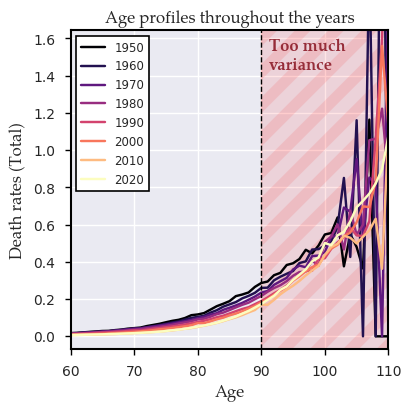

In [57]:
uk_data_all_ages = CountryData(country_hmd_code="GBRTENW")
uk_data_all_ages.load_data(1950, 2020, maximum_age=120)

bg_rect = patches.Rectangle(
    (90, -3), 30, 5.5,
    facecolor="red",
    alpha=0.1,
    linewidth=0,
    zorder=1
)

# doesnt work if its all in one, had to separate it (the export to pdf)
hatch_rect = patches.Rectangle(
    (90, -3), 30, 5.5,
    facecolor="none", 
    edgecolor="red",
    hatch="/",
    alpha=0.1,
    hatch_linewidth = 8
)

ax = uk_data_all_ages.plot_age_profiles(year_step=10, legend_size=8.5)
ax.add_patch(bg_rect)
ax.add_patch(hatch_rect)
ax.text(91.25, 1.6, "Too much \nvariance", fontsize=12, 
        fontname="Tex Gyre Pagella", color = "#962d39",
        fontweight="bold", ha = "left", va="top")
fig = ax.get_figure()
fig.set_size_inches(4,4)
fig.set_layout_engine("constrained")
#fig.savefig("figure.pdf")
plt.show()

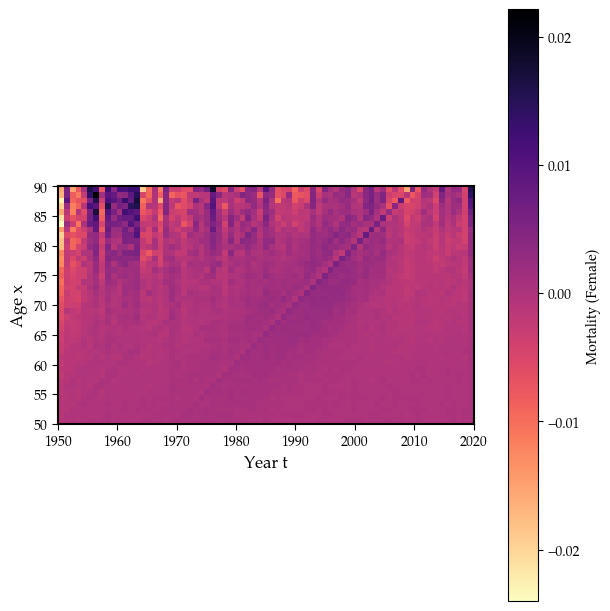

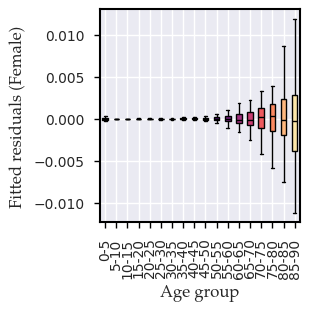

In [58]:
def homoskedasticity_showcase(country_code, value_column, min_year, max_year, min_age, max_age):
    _, model = train_model_pipeline(country_code, value_column, min_year, max_year)
    fig1, ax1 = plt.subplots(figsize=(6, 6), layout="constrained")
    errors = model.wide_matrix - model.predict_historical()
    im = ax1.imshow(
        errors.to_pandas().query("Age >= @min_age and Age <= @max_age"),
        cmap="magma_r",
        extent=[min_year, max_year, max_age, min_age]
    )

    ax1.invert_yaxis()
    cbar = fig1.colorbar(im, ax=ax1, label=f"Mortality ({value_column})")
    plot_configuration(ax1)
    ax1.set_xlabel("Year t")
    ax1.set_ylabel("Age x")
    fig1.savefig(f"created_plots/{country_code}_{value_column}_errorheatmap.pdf", bbox_inches=None)

    with plt.style.context("seaborn-v0_8"):
        fig2, ax2 = plt.subplots(figsize=(3,3), layout="constrained")
        bin_size = 5
        errors_grouped = errors.groupby_bins("Age",
                                            np.arange(0, max_age+1, bin_size), 
                                            include_lowest=True).mean().to_pandas()
        x_tick_labels = [f"{i.left}-{i.right}" for i in errors.groupby_bins("Age", np.arange(0, max_age+1, bin_size))
                        .mean().to_pandas().index.values]
        n_boxes = len(x_tick_labels)
        magma_colors = plt.cm.magma(np.linspace(0.15, 0.95, len(x_tick_labels[n_boxes//2:])))
        bplots = ax2.boxplot(errors_grouped.T, patch_artist=True, sym="", 
                             medianprops={"color": "black", "linewidth": 1})

        for patch, color in zip(bplots["boxes"][n_boxes//2:], magma_colors):
            patch.set_facecolor(color)

        ax2.set_xticklabels(x_tick_labels, rotation=90)
        plot_configuration(ax2)
        ax2.set_xlabel("Age group")
        ax2.set_ylabel(f"Fitted residuals ({value_column})")
        fig2.savefig(f"created_plots/{country_code}_{value_column}_errorboxplots.pdf", bbox_inches=None)
    plt.show()

homoskedasticity_showcase("GBRTENW", "Female", 1950, 2020, 50, 90)

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


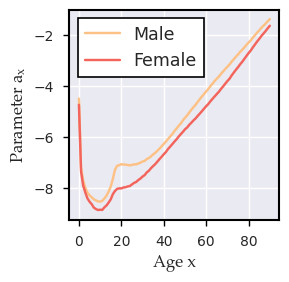

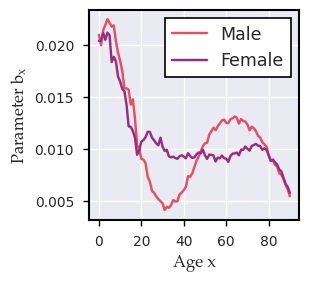

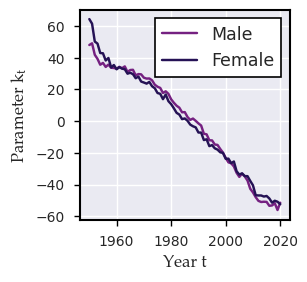

In [59]:
def show_estimated_parameters_lc(country_code, min_year, max_year, colors=colors):
    _, lc_model_male = train_model_pipeline(country_code, "Male", min_year, max_year)
    _, lc_model_female = train_model_pipeline(country_code, "Female", min_year, max_year)
    with plt.style.context("seaborn-v0_8"):
        fig1, ax1 = plt.subplots(figsize=(3, 3), layout="constrained")
        fig2, ax2 = plt.subplots(figsize=(3, 3), layout="constrained")
        fig3, ax3 = plt.subplots(figsize=(3, 3), layout="constrained")

        axs = [[ax1, "ax"], [ax2, "bx"], [ax3, "kt"]]

        for i, lc_model in enumerate([lc_model_male, lc_model_female]):
            axs[0][0].plot(
                np.arange(0, 91, 1),
                lc_model.ax,
                color=colors[3 + i*7],
                label=lc_model.value_column
            )
            #axs[0].set_title("ax")
            axs[0][0].set_xlabel("Age x")
            axs[0][0].set_ylabel("Parameter $a_x$")

            axs[1][0].plot(
                np.arange(0, 91, 1),
                lc_model.bx,
                color=colors[12 + i*7],
                label=lc_model.value_column
            )
            #axs[1].set_title("bx")
            axs[1][0].set_xlabel("Age x")
            axs[1][0].set_ylabel("Parameter $b_x$")

            axs[2][0].plot(
                np.arange(min_year, max_year + 1, 1),
                lc_model.kt,
                color=colors[22 + i*7],
                label=lc_model.value_column
            )
            #axs[2].set_title("kt")
            axs[2][0].set_xlabel("Year t")
            axs[2][0].set_ylabel("Parameter $k_t$")

        axs[0][0] = plot_configuration(axs[0][0], legend_location="upper left")
        axs[1][0] = plot_configuration(axs[1][0], legend_location="upper right")
        axs[2][0] = plot_configuration(axs[2][0], legend_location="upper right")
        for i in range(len(axs)):
            ax = axs[i][0]
            fig = ax.get_figure()
            fig.set_layout_engine(None) 
            ax.set_position([0.27, 0.2, 0.7, 0.7])
            ax.set_box_aspect(1)

        return axs

country_code, value_column = "GBRTENW", "Male"
axs = show_estimated_parameters_lc(country_code, 1950, 2020)
for i in range(len(axs)):
    fig = axs[i][0].get_figure()
    axs[i][0].set_box_aspect(1)
    fig.savefig(f"created_plots/{country_code}_lc_{axs[i][1]}.pdf", bbox_inches=None)
plt.show()

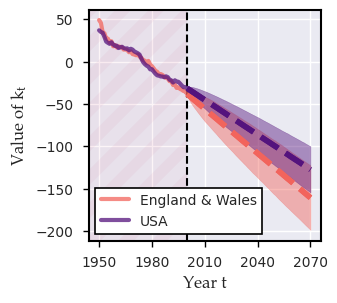

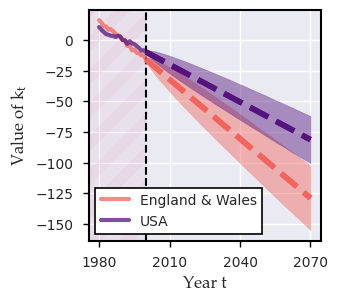

In [60]:
def compare_kt_intervals(
        country_code, 
        value_column,
        min_year, 
        max_year, 
        split_year, 
        simulations, 
        ax = None
    ):
    data, lc_model, mortality_evaluation = \
        train_model_pipeline(
            country_code, 
            value_column, 
            min_year, 
            max_year, 
            split_year, 
            simulations=simulations,
            overlap=True
    )

    steps = max_year - split_year
    years_historical = np.arange(min_year, split_year + 1)
    years_forecast = np.arange(split_year, max_year + 1)
    
    kt_analytical_forecast = lc_model.predict_kt_analytical(steps)
    kt_mc_forecast = lc_model.predict_kt(steps, simulations)

    drift = (lc_model.kt[-1] - lc_model.kt[0]) / (len(lc_model.kt) - 1)
    std_of_errors = np.std(np.diff(lc_model.kt) - drift)

    theo_lower_pi = kt_analytical_forecast - 1.96 * np.sqrt(np.arange(0, steps + 1)) * std_of_errors
    theo_upper_pi = kt_analytical_forecast + 1.96 * np.sqrt(np.arange(0, steps + 1)) * std_of_errors

    mc_lower_pi = kt_mc_forecast.quantile(0.025, dim="Simulation").to_numpy()
    mc_upper_pi = kt_mc_forecast.quantile(0.975, dim="Simulation").to_numpy()

    with plt.style.context("seaborn-v0_8"):
        if not ax:
            fig, ax = plt.subplots(figsize=(3,3))
            ax.axvline(split_year, linestyle="dashed", color="black", linewidth=1.5)
            ax.set_xlabel("Year t")
            ax.set_ylabel("Value of $k_t$")
        
        count_of_plots = (len(ax.lines) - 1) // 2
        ax.plot( # historical line
            years_historical,
            lc_model.kt,
            color=colors[10 + 15*count_of_plots],
            linewidth=3,
            alpha=0.75,
            label=data.country_name
        )
        ax.plot( # analytical forecast
            years_forecast,
            kt_analytical_forecast,
            color=colors[10 + 15*count_of_plots],
            linewidth=4,
            linestyle="dashed"
        )
        ax.fill_between( # analytical prediction interval
            years_forecast,
            theo_lower_pi,
            theo_upper_pi,
            alpha=0.25,
            color=colors[10 + 15*count_of_plots]
        )
        ax.plot(  # monte carlo forecast
            years_forecast,
            kt_mc_forecast.median(dim="Simulation"),
            color=colors[10 + 15*count_of_plots],
            linewidth=4,
            linestyle="dashed"
        )
        ax.fill_between(  # monte carlo prediction interval
            years_forecast,
            mc_lower_pi,
            mc_upper_pi,
            alpha=0.25,
            color=colors[10 + 15*count_of_plots]
        )
        plot_configuration(ax, legend_location="lower left", legend_size=10)
        
        if not ax.patches:
            y_lims = ax.get_ylim()
            x_lims = ax.get_xlim()
            rect = patches.Rectangle(
                    (split_year, -1000), -100, 2000,
                    facecolor=colors[15],
                    alpha=0.05
            )
            hatch_rect = patches.Rectangle(
                    (split_year, -1000), -100, 2000,
                    facecolor="none", 
                    edgecolor=colors[15],
                    hatch="/",
                    alpha=0.05,
                    hatch_linewidth = 8
            )
            ax.add_patch(rect)
            ax.add_patch(hatch_rect)
            ax.set_ylim(y_lims)
            ax.set_xlim(x_lims)
        ax.set_xticks(np.arange(min_year, max_year + 1, 30))
    return ax

ax_kt_ints = compare_kt_intervals("GBRTENW", "Female", 1950, 2070, 2000, simulations=10000)
ax_kt_ints = compare_kt_intervals("USA", "Female", 1950, 2070, 2000, simulations=10000, ax=ax_kt_ints)
ax_kt_ints.get_figure().savefig(f"created_plots/Female_long_kt_pred.pdf", bbox_inches="tight")

ax_kt_ints_2 = compare_kt_intervals("GBRTENW", "Female", 1980, 2070, 2000, simulations=10000)
ax_kt_ints_2 = compare_kt_intervals("USA", "Female", 1980, 2070, 2000, simulations=10000, ax=ax_kt_ints_2)
ax_kt_ints_2.get_figure().savefig(f"created_plots/Female_short_kt_pred.pdf", bbox_inches="tight")

plt.show()

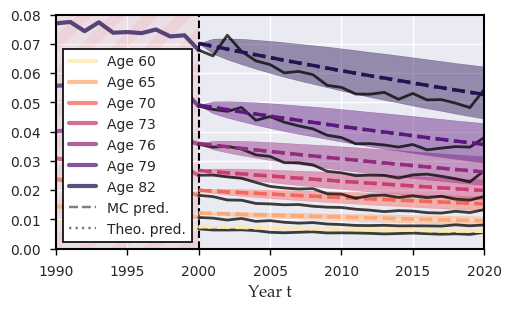

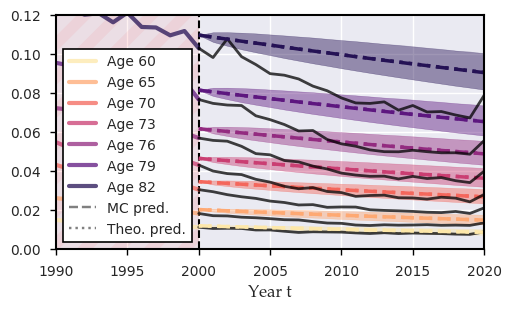

In [61]:
def compare_mxt_intervals(
        country_code, 
        value_column, 
        min_year, 
        max_year, 
        split_year,
        steps,
        simulations, 
        ages
    ):
    data, lc_model, mortality_evaluation = \
        train_model_pipeline(country_code, value_column, min_year, max_year, split_year, True, simulations)
    historical_mxt_values = data.mx.get_pivoted_data(value_column).sel(Year=slice(min_year, max_year))
    mc_mxt_forecast = lc_model.predict(steps, simulations)
    theo_mxt_forecast = lc_model.predict(steps, 1, False) 

    years_historical = np.arange(min_year, split_year + 1)
    years_testing = np.arange(split_year, max_year + 1)
    years_forecast = np.arange(split_year, split_year + steps + 1)

    with plt.style.context("seaborn-v0_8"):
        colors = plt.cm.magma(np.linspace(0.95, 0.15, len(ages)))
        fig, ax = plt.subplots(figsize=(5,3), layout="constrained")
        ax.axvline(split_year, linestyle="dashed", color="black", linewidth=1.5)
        ax.set_xlabel("Year t")
        
        for i, age in enumerate(ages):
            theo_lower_pi = theo_mxt_forecast.sel(Age=age).to_numpy() * np.exp(
                -1.96 * lc_model.bx[age] * np.sqrt(np.arange(0, steps+1)) * lc_model.std_of_errors
            )
            theo_upper_pi = theo_mxt_forecast.sel(Age=age).to_numpy() * np.exp(
                1.96 * lc_model.bx[age] * np.sqrt(np.arange(0, steps+1)) * lc_model.std_of_errors
            )
            mc_lower_pi = mc_mxt_forecast.sel(Age=age).quantile(0.025, dim="Simulation").to_numpy()
            mc_upper_pi = mc_mxt_forecast.sel(Age=age).quantile(0.975, dim="Simulation").to_numpy()
        
            ax.plot( # historical lines
                years_historical,
                historical_mxt_values.sel(Age=age, Year=slice(min_year, split_year)),
                color=colors[i],
                linewidth=3,
                alpha=0.75,
                label=f"Age {age}"
            )
            ax.plot( # testing set lines
                years_testing,
                historical_mxt_values.sel(Age=age, Year=slice(split_year, max_year)),
                color="black",
                linewidth=2,
                alpha=0.75,
            )

            ax.plot( # analytical forecasts
                years_forecast,
                theo_mxt_forecast.sel(Age=age),
                color=colors[i],
                linewidth=2.5,
                linestyle="dotted"
            )
            ax.fill_between( # analytical prediction intervals
                years_forecast,
                theo_lower_pi,
                theo_upper_pi,
                alpha=0.25,
                color=colors[i]
            )
            ax.plot( # monte carlo forecasts
                years_forecast,
                mc_mxt_forecast.sel(Age=age).median(dim="Simulation"),
                color=colors[i],
                linewidth=2.5,
                linestyle="dashed"
            )
            ax.fill_between( # monte carlo prediction intervals
                years_forecast,
                mc_lower_pi,
                mc_upper_pi,
                alpha=0.25,
                color=colors[i]
            )

        ax.plot([np.nan], [np.nan], color="gray", linestyle="dashed", label="MC pred.")
        ax.plot([np.nan], [np.nan], color="gray", linestyle="dotted", label="Theo. pred.")

        y_lims = ax.get_ylim()
        x_lims = ax.get_xlim()
        rect = patches.Rectangle(
                (split_year, -1000), -100, 2000,
                facecolor="red",
                alpha=0.05
        )
        hatch_rect = patches.Rectangle(
                (split_year, -1000), -100, 2000,
                facecolor="none", 
                edgecolor="red",
                hatch="/",
                alpha=0.05,
                hatch_linewidth = 8
        )
        ax.add_patch(rect)
        ax.add_patch(hatch_rect)
        ax.set_ylim(y_lims)
        ax.set_xlim(x_lims)
        plot_configuration(ax, legend_location="lower left", legend_size=10)
        ax.set_xticks(np.arange(min_year, split_year + steps + 1, 5))

        return ax
    
mxt_preds_params = {
    "country_code": "GBRTENW",
    "min_year": 1950,
    "max_year": 2020,
    "split_year": 2000,
    "steps": 20,
    "simulations": 10000,
    "ages": [60, 65, 70, 73, 76, 79, 82]
}
ax_mxt_1 = compare_mxt_intervals(value_column="Female", **mxt_preds_params)
ax_mxt_1.set_xlim((1990, 2020))
ax_mxt_1.set_ylim((0.0, 0.08))
ax_mxt_1.get_figure().savefig(
    f"created_plots/{mxt_preds_params["country_code"]}_Female_mxt_preds.pdf", bbox_inches=None
)

ax_mxt_2 = compare_mxt_intervals(value_column="Male", **mxt_preds_params)
ax_mxt_2.set_xlim((1990, 2020))
ax_mxt_2.set_ylim((0.0, 0.12))
ax_mxt_2.get_figure().savefig(
    f"created_plots/{mxt_preds_params["country_code"]}_Male_mxt_preds.pdf", bbox_inches=None
)

plt.show()

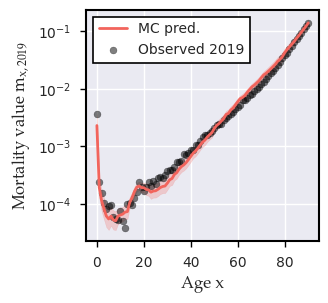

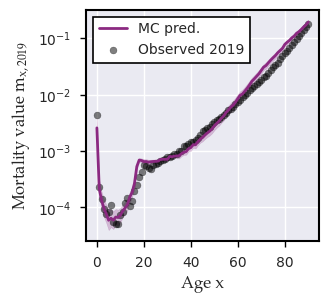

In [62]:
def plot_mx_snapshot_pipeline(
        country_code, 
        value_column, 
        min_year, 
        max_year, 
        split_year,
        target_year,
        simulations,
        color_idx
    ):
    data, lc_model, mortality_evaluation = \
        train_model_pipeline(country_code, value_column, min_year, max_year, split_year, True, simulations)
    
    mc_mxt_forecast = lc_model.predict(max_year - split_year, simulations)
    observed_all = data.mx.get_pivoted_data(value_column)
    observed_snapshot = observed_all.sel(Year=target_year)
    prediction_snapshot = mc_mxt_forecast.sel(Year=target_year)

    ages = observed_snapshot.Age.values
    
    with plt.style.context("seaborn-v0_8"):
        colors = plt.cm.magma(np.linspace(0.95, 0.15, 30))
        fig, ax = plt.subplots(figsize=(3, 3))
        
        ax.fill_between(
            ages, 
            prediction_snapshot.quantile(0.025, dim="Simulation").to_numpy(),
            prediction_snapshot.quantile(0.975, dim="Simulation").to_numpy(),
            color=colors[color_idx], 
            alpha=0.25
        )
        ax.plot(
            ages, 
            prediction_snapshot.median(dim="Simulation").to_numpy(), 
            color=colors[color_idx], 
            linewidth=2, 
            label="MC pred."
        )
        ax.scatter(
            ages, 
            observed_snapshot.to_numpy(), 
            color="black", 
            s=25, 
            alpha=0.5, 
            label=f"Observed {target_year}"
        )
        
        ax.set_yscale("log")
        ax.set_xlabel("Age x")
        ax.set_ylabel("Mortality value $m_{x,2019}$")
        plot_configuration(ax, legend_location="upper left", legend_size=10)
        
        return ax
    
mxt_snapshot_params = {
    "country_code": "GBRTENW",
    "min_year": 1950,
    "max_year": 2020,
    "split_year": 2000,
    "simulations": 10000,
    "target_year": 2019
}

ax_mxt_snap_1 = plot_mx_snapshot_pipeline(value_column="Female", color_idx=10, **mxt_snapshot_params)
ax_mxt_snap_1.get_figure().savefig(
    f"created_plots/{mxt_snapshot_params["country_code"]}_Female_mxt_snapshot.pdf", bbox_inches="tight"
)
ax_mxt_snap_2 = plot_mx_snapshot_pipeline(value_column="Male", color_idx=20, **mxt_snapshot_params)
ax_mxt_snap_2.get_figure().savefig(
    f"created_plots/{mxt_snapshot_params["country_code"]}_Male_mxt_snapshot.pdf", bbox_inches="tight"
)


plt.show()